## **Giảm chiều và trực quan hóa chữ số viết tay bằng t-SNE.**

In [32]:
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
from core.evaluation import load_optdigits_csv, run_evaluation  
from core.tsne_numpy import TSNE 

#### **Tiền xử lí dữ liệu**

In [14]:
# Đọc dữ liệu hai file data gốc  
train = pd.read_csv (r'data\raw\optdigits.tra' , header= None )
test = pd.read_csv (r'data\raw\optdigits.tes' , header= None )  

print ('==== Value null ==== ')  
print ( "Null train :" ,train.isnull ().sum ( ).sum ()) 
print ( "Null test :" , test.isnull ().sum ().sum ())

print ('Shape train :' , train.shape)  
print ('Shape test :', test.shape )
# Gôp file thông qua concat 
data = pd.concat ([train  , test ] , ignore_index= True  ,axis= 0 )  

print ('=' * 20 )  
print ('Shape data : ' ,  data.shape  )    



==== Value null ==== 
Null train : 0
Null test : 0
Shape train : (3823, 65)
Shape test : (1797, 65)
Shape data :  (5620, 65)


In [15]:
# Lưu dataset sau xử lí  

column_names= [f'Pixel_{i}' for i in range (1 , 65) ]  
data.columns =  column_names + ['label']  
data.to_csv (r'data\processed\optdigits.csv') 

data

,Pixel_1,Pixel_2,Pixel_3,Pixel_4,Pixel_5,Pixel_6,Pixel_7,Pixel_8,Pixel_9,Pixel_10,...,Pixel_56,Pixel_57,Pixel_58,Pixel_59,Pixel_60,Pixel_61,Pixel_62,Pixel_63,Pixel_64,label
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,1,15,2,0,0,4
4,0,0,5,14,4,0,0,0,0,0,...,0,0,0,4,12,14,7,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5615,0,0,4,10,13,6,0,0,0,1,...,0,0,0,2,14,15,9,0,0,9
5616,0,0,6,16,13,11,1,0,0,0,...,0,0,0,6,16,14,6,0,0,0
5617,0,0,1,11,15,1,0,0,0,0,...,0,0,0,2,9,13,6,0,0,8
5618,0,0,2,10,7,0,0,0,0,0,...,0,0,0,5,12,16,12,0,0,9


#### **Traning và tiến hành thử nghiệm đánh giá kết quả trực quan dữ liệu**

In [21]:
# Load dataset 
X, y  = load_optdigits_csv (r'data\processed\optdigits.csv') 

X_test = X[:2000]  # Thử nghiệm với 2000 mẫu dữ liệu 
y_test = y[:2000]
# Đánh giá thử nghiệm trên nhiều giá perflexity và visualize kết quả 
results = run_evaluation(
    X_test,
    y_test ,
    perplexities=[5, 10, 15, 20, 25, 30, 45, 50],
    n_iter=500,
    random_state=42,
    output_dir="outputs",
    verbose=True )    





=== Perplexity = 5 ===
Vòng lặp    0: KL divergence = 100.591683
Vòng lặp  100: KL divergence = 79.172687
Vòng lặp  200: KL divergence = 73.503057
Vòng lặp  300: KL divergence = 1.705898
Vòng lặp  400: KL divergence = 1.032799
Vòng lặp  499: KL divergence = 0.845660
  KL Divergence   : 0.844426
  Runtime (s)     : 162.95
  Trustworthiness : 0.998132

=== Perplexity = 10 ===
Vòng lặp    0: KL divergence = 92.641749
Vòng lặp  100: KL divergence = 71.546153
Vòng lặp  200: KL divergence = 67.435502
Vòng lặp  300: KL divergence = 1.382025
Vòng lặp  400: KL divergence = 0.862380
Vòng lặp  499: KL divergence = 0.737871
  KL Divergence   : 0.737080
  Runtime (s)     : 101.30
  Trustworthiness : 0.998589

=== Perplexity = 15 ===
Vòng lặp    0: KL divergence = 87.918725
Vòng lặp  100: KL divergence = 67.336033
Vòng lặp  200: KL divergence = 64.314053
Vòng lặp  300: KL divergence = 1.236701
Vòng lặp  400: KL divergence = 0.780946
Vòng lặp  499: KL divergence = 0.684417
  KL Divergence   : 0.6838

d:\t-SNE\core\evaluation.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Đã lưu 4 hình vào: outputs\figures


In [22]:
# Kết quả đánh từng perflexity  
print (results )

   perplexity  kl_divergence  runtime_sec  trustworthiness
0           5       0.844426   162.954578         0.998132
1          10       0.737080   101.298003         0.998589
2          15       0.683824    95.572366         0.998723
3          20       0.638327    67.866470         0.998752
4          25       0.598247    64.014098         0.998730
5          30       0.579535    53.602023         0.998574
6          45       0.462929    53.225520         0.998049
7          50       0.437503    52.347855         0.997870


####  **--> Trong các giá trị perplexity đã thử nghiệm, khoảng 20–30 cho kết quả phù hợp nhất. Perplexity = 25 được chọn để trực quan hóa cuối cùng vì có Trustworthiness rất cao đồng thời KL Divergence tương đối thấp..**

In [23]:
# Chạy trên toàn bộ dataset với perflexity 25   

model_t_SNE =  TSNE(
    n_components=2,
    perplexity=25,
    n_iter=1000,
    random_state=42,
    verbose=True
)

dataset_2d  = model_t_SNE.fit_tranform (X)  

Vòng lặp    0: KL divergence = 94.346440
Vòng lặp  100: KL divergence = 70.179110
Vòng lặp  200: KL divergence = 64.559505
Vòng lặp  300: KL divergence = 1.749404
Vòng lặp  400: KL divergence = 1.086681
Vòng lặp  500: KL divergence = 0.877643
Vòng lặp  600: KL divergence = 0.781706
Vòng lặp  700: KL divergence = 0.727367
Vòng lặp  800: KL divergence = 0.692494
Vòng lặp  900: KL divergence = 0.668070
Vòng lặp  999: KL divergence = 0.650175


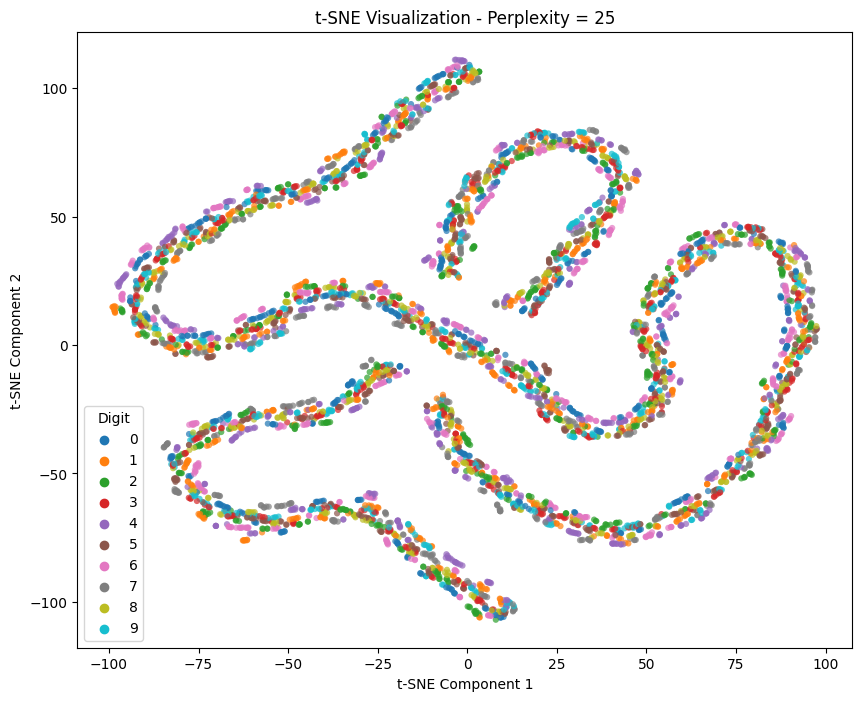

In [34]:
# Trực quan hóa dữ liệu dưới dạng 2d 

# Tạo DataFrame để trực quan hóa
df_2d = pd.DataFrame({
    "Component 1": dataset_2d[:, 0],
    "Component 2": dataset_2d[:, 1],
    "Label": y
})

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_2d,
    x="Component 1",
    y="Component 2",
    hue="Label",
    palette="tab10",
    s=20,
    alpha=0.7,
    linewidth=0
)

plt.title("t-SNE Visualization - Perplexity = 25")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Digit")

# Lưu ảnh kết quả trực quan 
plt.savefig(
    "outputs/figures/tsne_perplexity_25.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()